# Atelier "Coder sa première IA sous Python" (durée : 3h)

### Installation
```bash
sudo apt update
sudo apt install -y python3.11 python3.11-venv python3-pip

cd /chemin/vers/fds2025

python3.11 -m venv .venv
source .venv/bin/activate

python -m pip install --upgrade pip
python -m pip install -r requirements.txt

python -m ipykernel install --user \
  --name fds2025 \
  --display-name "Python 3.11 (fds2025)"

jupyter lab
````

1. Penser à déposer le dossier sur chaque ordi
2. Chaque étudiant aura sa session jupyter déjà ouverte.

## Déroulé


1. On se présente
2. Amorcer intro
3. Plan : trois parties
   -> à la fin comprendre comment une "IA" fait pour reconnaître des nombres


## Introduction (5-10')

❓ <strong> À interroger en classe :</strong> écrire les mots au tableau

- Qu’est-ce qu’une intelligence artificielle (IA) ?

L'IA est une notion forgée au milieu des années 1950, dans la foulée des réflexions du mathématicien Alan Turing, qui se demandait si un ordinateur saurait un jour "penser", ou s’il n’était capable que d’un "jeu d’imitation" (imitation game). 
Il existe plusieurs définitions. Voici celle donnée par le Parlement européen qui définit l’intelligence artificielle comme tout outil utilisé par une machine capable de "reproduire des comportements liés aux humains, tels que le raisonnement, la planification et la créativité".

Src : https://www.enseignementsup-recherche.gouv.fr/fr/intelligence-artificielle-de-quoi-parle-t-91190 

Idée clé : « Une IA, c’est un programme qui apprend à partir de données. »

Insister sur la notion qu’une IA ne se limite pas qu’à ChatGPT (qui est un type)

- Dans quels objets du quotidien on retrouve de l'IA aujourd'hui ? Exemples simples (chatGPT/moteur de recherche, voiture autonome, reconnaissance d’image, assistant vocal, assistant de recommandations dans Youtube ou Netflix).



- Utilisent-ils des IA ? Comment les utilisent-ils ?

## Préalables (20')

Fait en live par Vincent

On garde (voir notes activité secondes juin 2026)

*Temps indicatif : 1h*

## Activité 1 - Régression linéaire (durée estimée : 30min)

> 📌 <strong> Fonctions connues au lycée :</strong> 
> - affine, carré, inverse, racine carrée
> - sinus, cosinus, tangente

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<h3> Déroulé</h3>
    <ol>
        <li>Faire un rappel de la fonction affine via l'étude du jeu <code>jeu1.csv</code> qui représente des données parfaitement alignées suivant une <b> droite affine </b> où les paramètres seront à estimer <b> à la main </b> comme ils ont appris en cours</li>
        <li>Tranquillement aller sur un <b> nuage de points </b> (<code>jeu2.csv</code>) où ils essayeront d'estimer visuellement les paramètres / on introduira la notion d'<b>erreur</b> </li>
        <li>En partant de ce même <b> nuage de points </b> leur montrer comment on peut estimer les paramètres automatiquement avec la <b> descente de gradient </b> </li>
    </ol>
</div>

### Chargement des bibliothèques Python nécessaires
📌 Rappel : une **bibliothèque** Python est une boîte à outils de fonctions que le programmeur peut réutiliser.

Exécutez la celle ci-dessous :

In [2]:
# numpy est une bibliothèque qui permet de faire des calculs scientifiques avec des tableaux de nombres (vecteurs, matrices)
import numpy as np

# matplotlib permet de dessiner des graphiques, comme des nuages de points ou des courbes
# On l’utilise pour visualiser les données ou voir si notre IA fonctionne bien
import matplotlib.pyplot as plt

# gestion d'un jeu de données
import pandas as pd

### Définition – Qu’est-ce qu’une donnée ?

> Une **donnée**, c’est une information que l’on peut observer et mesurer.

Par exemple :
- la température d’un jour donné,
- la taille d’un élève,
- la note obtenue à un devoir,
- la couleur d’un pixel sur une image.

### Jeu de données n°1

🧑‍🏫 Pour les enseignants : 

In [37]:
# Génération des données (droite + bruit)
x = np.arange(0, 10)
y = 5 * x + 3

# Sauvegarde dans un DataFrame
df = pd.DataFrame({'x': x, 'y': y})

# Enregistrement en CSV
df.to_csv('jeu1.csv', index=False)

#### ✍️ Q1) **À vous de jouer !**

> Charger et visualiser les données en exécutant les cellules suivantes.

Pensez à bien exécuter les cellules l'une après l'autre.

In [2]:
# Chargement des données depuis le fichier CSV
data = np.loadtxt('jeu1.csv', delimiter=',', skiprows=1)

# Séparer les colonnes x et y
x = data[:, 0]
y = data[:, 1]

Pensez à dire que l'axe des ordonnés a été décalé

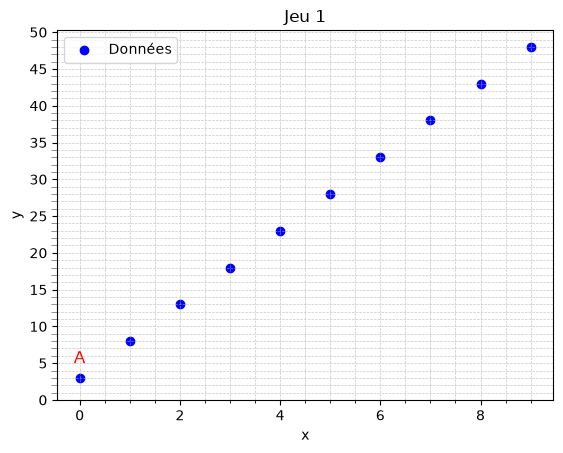

In [3]:
# Tracé
plt.scatter(x, y, label="Données", color="blue")

# Affiche le premier point A - on dispose de 10 points
plt.text(x[0], y[0] + 2, "A", ha="center", color="red", fontsize=12)

# Nomme les axes X et Y
plt.xlabel("x")
plt.ylabel("y")
plt.title("Jeu 1")

# Paramètres de visualisation
plt.yticks(np.arange(0, 55, 5))
plt.minorticks_on()
plt.tick_params(axis='y', which='minor', length=4, color='gray')

# Grille
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.legend() # Affiche la légende
plt.show() # Affiche le graphique

> Qu'observez-vous ?

Réponse : [double-clic pour répondre]

*🧑‍🏫  N.B : on pourra faire les rappels à ce moment-là pour les laisser faire individuellement après sans nécessairement faire une correction au tableau mais en passant individuellement dans les rangs.*

> Calculer la **pente** `a` et l'**ordonnée à l'orgine** `b`

Pour accéder aux coordonnées d'un point, par exemple pour le point A dans le graphique, on fera <code>x[0] y[0]</code>. Pour rappel, on commence les index à 0.

*🧑‍🏫  N.B : c'est quelque chose qu'ils peuvent avoir déjà cherché à automatiser d'après le programme des secondes (section automatisation).*

In [8]:
x[1]

np.float64(1.0)

In [7]:
y[1]

np.float64(8.0)

In [ ]:
a = # à calculer
b = # à calculer

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<h4>📌 Rappels</h4>
</div>

##### Fonction affine

- Une **fonction affine** est une fonction de la forme :

$$
f(x) = a \cdot x + b
$$

→ $ a $ est appelé le **coefficient directeur** (la pente de la droite) <br>
→ $ b $ est l’**ordonnée à l’origine** (là où la droite coupe l’axe vertical)

##### Estimer l’équation d’une droite affine

**Étapes pour déterminer l’équation d’une droite à partir de deux points :**

🔹 1. Repérer deux points de la droite

Par exemple, si on connaît deux points :

$$
A(x_1, y_1) \quad \text{et} \quad B(x_2, y_2)
$$

🔹 2. Calculer le coefficient directeur $a$

$$
a = \frac{y_2 - y_1}{x_2 - x_1}
$$

🔹 3. Calculer l’ordonnée à l’origine $b$

On résout l'équation $y = a x + b$ avec un des deux points pour trouver $b$ :

$$
b = y_1 - a \cdot x_1
$$

ou

$$
b = y_2 - a \cdot x_2
$$

---

**A partir du jeu1 :**

Soit les points $A(0, 3)$ et $B(1, 8)$ :

1. $a = \frac{8 - 3}{1- 0} = 5$
2. $b = 3 - 5 \cdot 0 = 3$

👉 Donc l’équation est :

$$
y = 5x - 3
$$

<div style="background-color:#f9f9f9; border-left:4px solid #0074D9; padding:0.5em; font-style: italic;">
Correction
</div>

In [9]:
a = (y[0] - y[1]) / (x[0] - x[1])  # Calcul du coefficient directeur (pente) entre les points A et B
print(a)
b = y[0] - a * x[0]  # Calcul de l'ordonnée à l'origine (intercept) en utilisant le point A
print(b)

5.0
3.0


Vous pouvez maintenant tracer la droite passant par ces points :

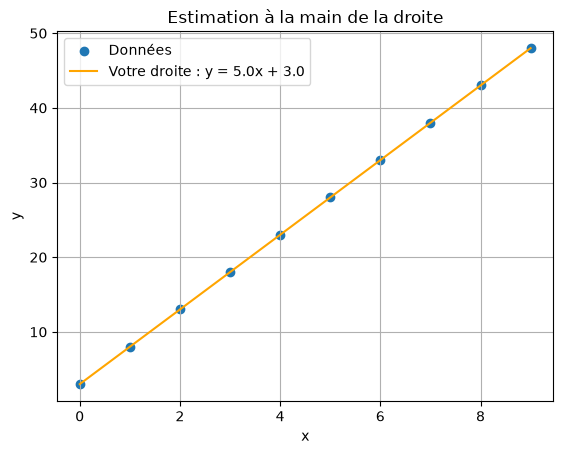

In [10]:
# Tracé
plt.scatter(x, y, label="Données")
plt.plot(x, a * x + b, color='orange', label=f"Votre droite : y = {a}x + {b}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Estimation à la main de la droite")
plt.grid(True)
plt.legend()
plt.show()

<div style="background-color:#f9f9f9; border-left:4px solid #0074D9; padding:0.5em; font-style: italic;">
Correction
</div>

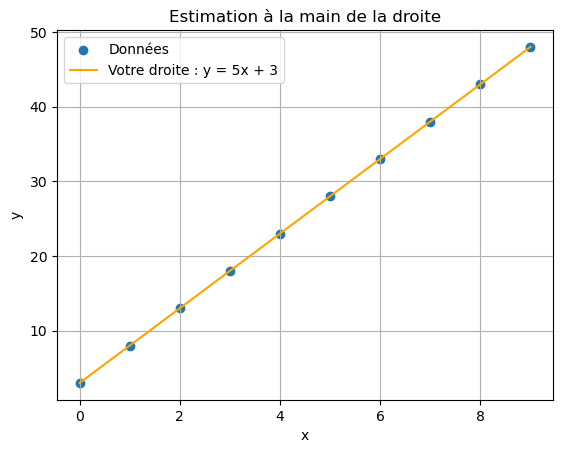

In [43]:
# Tracé
a = 5
b = 3
plt.scatter(x, y, label="Données")
plt.plot(x, a * x + b, color='orange', label=f"Votre droite : y = {a}x + {b}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Estimation à la main de la droite")
plt.grid(True)
plt.legend()
plt.show()

### Jeu de données n°2

🧑‍🏫 Pour les enseignants : 

In [21]:
# Code pour générer le jeu de données
import numpy as np
import pandas as pd

# Génération des données (droite + bruit)
x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.normal(0, 1, size=100)

# Sauvegarde dans un DataFrame
df = pd.DataFrame({'x': x, 'y': y})

# Enregistrement en CSV
df.to_csv('jeu2.csv', index=False)

---

#### ✍️ Q1) **À vous de jouer !**

> Observez le nuage de points suivant. Quelle différence avec le précédent ?

Pensez à bien exécuter les cellules l'une après l'autre.

In [22]:
# Chargement des données depuis le fichier CSV
data = np.loadtxt('jeu2.csv', delimiter=',', skiprows=1)

# Séparer les colonnes x et y
x = data[:, 0]
y = data[:, 1]

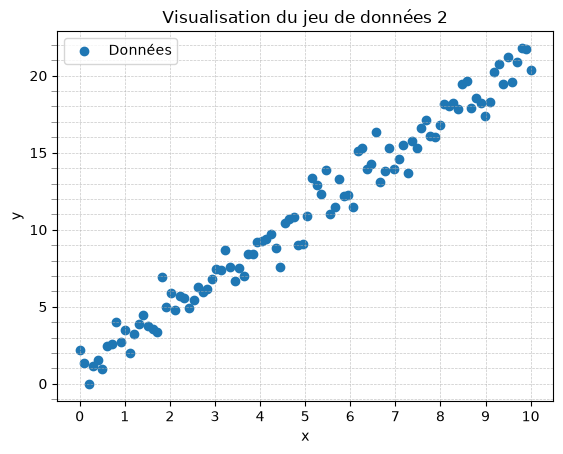

In [23]:
# Tracé
plt.scatter(x, y, label="Données")
plt.xlabel("x")
plt.ylabel("y")
plt.minorticks_on()
plt.yticks(np.arange(0, 23, 5))
plt.tick_params(axis='y', which='minor', length=4, color='gray')
plt.xticks(np.arange(0, 11, 1))
plt.tick_params(axis='x', which='minor', length=0, color='gray')
plt.title("Visualisation du jeu de données 2")
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7,  axis="y")
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7,  axis="x")
plt.legend()
plt.show()

Réponse : [double-clic pour répondre]

🧑‍🏫  *L'idée ici est de montrer qu'il est plus difficile de faire passer une droite par tous les points*

> **Essayez maintenant d’estimer l’équation de la droite** qui passe "au mieux" au milieu.

* Choisissez une **pente** `a_estime`,
* Choisissez une **ordonnée à l’origine** `b_estime`,
* Testez vos valeurs dans le code ci-dessous pour **voir si votre droite colle bien aux données** !

Vous pouvez réexécuter autant de fois la cellule suivante pour ajuster au mieux les paramètres :

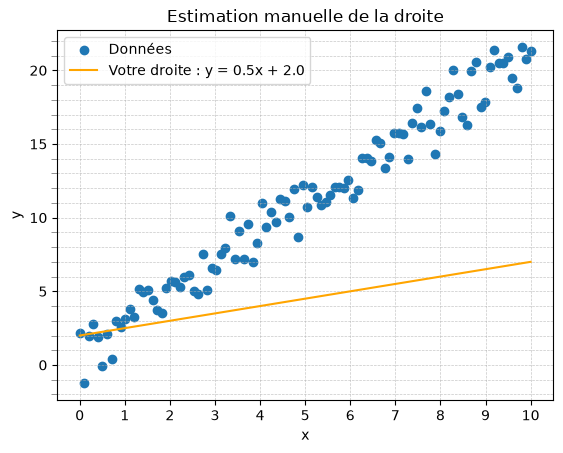

In [3]:
# Vos paramètres estimés
a_estime = 0.5  # à modifier
b_estime = 2.0  # à modifier

# Tracé
plt.scatter(x, y, label="Données")

plt.xlabel("x")
plt.ylabel("y")

plt.minorticks_on()
plt.yticks(np.arange(0, 23, 5))
plt.tick_params(axis='y', which='minor', length=4, color='gray')
plt.xticks(np.arange(0, 11, 1))
plt.tick_params(axis='x', which='minor', length=0, color='gray')

plt.plot(x, a_estime * x + b_estime, color='orange', label=f"Votre droite : y = {a_estime}x + {b_estime}")
plt.title("Estimation manuelle de la droite")
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7,  axis="y")
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7,  axis="x")
plt.legend()
plt.show()

<div style="background-color:#f9f9f9; border-left:4px solid #0074D9; padding:0.5em; font-style: italic;">
Correction
</div>

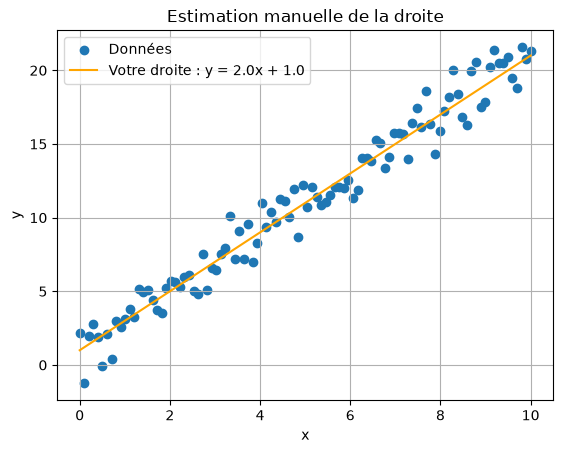

In [4]:
# Vos paramètres estimés
a_estime = 2.0
b_estime = 1.0

# Tracé
plt.scatter(x, y, label="Données")
plt.plot(x, a_estime * x + b_estime, color='orange', label=f"Votre droite : y = {a_estime}x + {b_estime}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Estimation manuelle de la droite")
plt.grid(True)
plt.legend()
plt.show()

#### Q2) **Évaluer la qualité de la droite estimée (modèle)**

N.B : revenir sur la notion de modèle

> En pratique, on calcule souvent un **indicateur de qualité** pour vérifier à quel point notre droite **représente bien la réalité** (c’est-à-dire les vraies données observées).

On peut par exemple comparer les valeurs prédites par ce modèle aux valeurs réelles observées. Cela permet de **mesurer à quel point on se trompe** : plus l’écart est grand, moins le modèle est bon.

Pour cela, on utilise une mesure appelée **erreur quadratique moyenne** — ou **MSE** (Mean Squared Error) :

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

avec :

* $ y_i $, la **valeur réelle** (dans les données) 
* $ \hat{y}_i $, la **valeur prédite** par le modèle où $\hat{y}_i = a*x_i +b$
* $\sum$ le symbole somme tel que $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = (y_1 - \hat{y}_1)^2 + (y_2 - \hat{y}_2)^2 + \ldots + (y_n - \hat{y}_n)^2$, $n$ étant le nombre de points


💡 On **élève la différence au carré** pour :

* éviter que les erreurs positives et négatives ne s’annulent,
* donner plus d’importance aux grandes erreurs.

➡️ **Plus la MSE est proche de 0, plus le modèle est précis.**

👉 À vous de coder cette erreur.

🧑‍🏫 Dans le code, `y_pred` = $\hat{y}$ 

🧑‍🏫  *L'idée est de mettre en pratique la boucle `for` et la notion de fonction qui reçoit plusieurs paramètres d'appel. La partie la plus difficile du TP.*

In [ ]:
# y : les vraies valeurs
# y_pred : les valeurs prédites

def f_predict(x,a_estime,b_estime):
    return # formule de la fonction affine

def mse(y, y_pred):
    return # à compléter ici

# Calcul de la MSE
y_pred = f_predict(x,a_estime,b_estime)
erreur_mse = mse(y, y_pred)

print("MSE =", erreur_mse)

<div style="background-color:#f9f9f9; border-left:4px solid #0074D9; padding:0.5em; font-style: italic;">
Correction
</div>

On pourra donner la fonction <code>np.mean</code>.

In [15]:
# y : les vraies valeurs
# y_pred : les valeurs prédites

a_estime = 2.0
b_estime = 1.0

def f_predict(x,a_estime,b_estime):
    return a_estime * x + b_estime

def mse(y, y_pred):
    return np.mean((y-y_pred)**2)

# Calcul de la MSE
y_pred = f_predict(x,a_estime,b_estime)
erreur_mse = mse(y, y_pred)

print("MSE =", erreur_mse)

MSE = 1.2508576293273144


Avec la boucle :

In [ ]:
# y : les vraies valeurs
# y_pred : les valeurs prédites

a_estime = 2.0
b_estime = 1.0

def f_predict(x,a_estime,b_estime):
    return a_estime * x + b_estime

def mse(y, y_pred):
    s = 0
    for i in range(len(y)):
        s+=(y[i]-y_pred[i])**2 #proposer l'opérateur pour mettre au carré 
    return s/len(y)

# Calcul de la MSE
y_pred = f_predict(x,a_estime,b_estime)
erreur_mse = mse(y, y_pred)

print("MSE =", erreur_mse)

MSE = 1.250857629327314


#### Q3) **Estimer automatiquement les bons paramètres**

Jusqu’ici, nous avons **choisi à la main** des valeurs pour la pente $a$ et l’ordonnée à l’origine $b$, en testant visuellement ce qui « colle » le mieux aux données.

Mais il existe des **méthodes automatiques** pour **trouver les meilleures valeurs possibles** :
👉 C’est ce que fait la **descente de gradient**.

---

##### 💡 C’est quoi l’idée ?

On cherche à **réduire l’erreur** entre ce que notre droite prédit et les vraies données.

On mesure cette erreur avec la mesure précédente la **MSE**.

---

##### 📉 La descente de gradient

La descente de gradient, c’est une méthode **pas à pas** pour **ajuster automatiquement les paramètres $a$ et $b$** afin de **réduire l’erreur MSE**.

C’est comme **descendre une pente** jusqu’au point le plus bas (là où l’erreur est minimale) :

On commence avec des paramètres choisis **au hasard**.

Puis, on répète les étapes suivantes :

1. On calcule l’**erreur** du modèle qui permet de mesurer à quel point notre prédiction est loin de la vraie réponse. Ici, elle représente une différence entre $y_{vrai}$ et $y_{pred}$. 
2. On regarde dans quelle **direction** on peut modifier les paramètres pour réduire l’erreur,
3. On fait un petit pas dans cette direction.

##### 📌 À retenir pour la régression linéaire :

> En IA, on veut **retrouver automatiquement** cette équation $y = a x + b$ **à partir d’un nuage de points**, même quand les points ne sont pas parfaitement alignés (cas bruité).
> C’est exactement ce que fait la **régression linéaire** : elle **apprend** les valeurs de $a$ et $b$ à partir des données. On n'a pas forcément de méthode exacte.

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<strong> 📌 Notes aux enseignants : </strong>
<ul>
    <li> Le concept de dérivée n'est vu qu'à partir de la première donc pas la peine de rentrer dans les détails mathématiques. Néanmoins, on pourra simplement mentionner que la direction dans laquelle les paramètres sont ajustés est liée à la variation de la fonction d’erreur : si la fonction "monte", on corrige dans l’autre sens. Cette direction est donnée par ce qu’on appelle le gradient, qui s’appuie sur les dérivées. On va dans le sens opposé à celui-ci, pour réduire progressivement l’erreur.
    </li>
    <li>Ouvrir sur le fait que la descente de gradient est une technique d'optimisation et que c'est tout un champ de recherche en maths-info.</li>
</ul>   
</div>


In [ ]:
# ===== 🧑‍🏫 Génération du GIF descente de gradient =====

import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

# --- Parabole et son gradient ---
f       = lambda x: x**2
grad_f  = lambda x: 2 * x

# --- Paramètres ---
x0     = 3.0
lr     = 0.8   # lr > 0.5 => oscillations gauche/droite, lr < 1 => convergence
n_iter = 18

# Séquence des positions  :  3 → -1.8 → 1.08 → -0.65 → … → 0
positions = [x0]
x = x0
for _ in range(n_iter):
    x = x - lr * grad_f(x)
    positions.append(x)

# --- Domaine ---
x_range = np.linspace(-3.5, 3.5, 400)
y_range = f(x_range)

# --- Animation ---
fig, ax = plt.subplots(figsize=(7, 5))

def animate(i):
    ax.clear()

    # Parabole
    ax.plot(x_range, y_range, color='steelblue', linewidth=2.5,
            label=r'$f(x) = x^2$')

    # Minimum
    ax.plot(0, 0, 'g*', markersize=16, zorder=6, label='Minimum (x = 0)')

    # Flèches de la trajectoire passée
    for j in range(i):
        alpha = 0.2 + 0.6 * (j / max(i, 1))
        ax.annotate('',
            xy=(positions[j+1], f(positions[j+1])),
            xytext=(positions[j],   f(positions[j])),
            arrowprops=dict(arrowstyle='->', color='gray',
                            lw=1.5, alpha=alpha))

    # Points visités (sauf le courant)
    if i > 0:
        px = positions[:i]
        py = [f(xi) for xi in px]
        ax.scatter(px, py, color='orange', s=50, alpha=0.55, zorder=4)

    # Point courant
    xi, yi = positions[i], f(positions[i])
    ax.scatter([xi], [yi], color='crimson', s=160, zorder=7,
               label=f'Étape {i} — x = {xi:.3f}  f(x) = {yi:.3f}')
    ax.vlines(xi, 0, yi, colors='crimson', linestyles='dotted',
              linewidth=1.3, alpha=0.5)

    ax.set_xlim(-3.8, 3.8)
    ax.set_ylim(-0.5, 10)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.set_title(
        f"Descente de gradient sur $f(x)=x^2$  (lr = {lr})",
        fontsize=12)
    ax.legend(loc='upper center', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(0, color='k', linewidth=0.5)

ani = animation.FuncAnimation(fig, animate,
                               frames=len(positions),
                               interval=600,
                               repeat=True, repeat_delay=2000)

output_path = './descente_gradient_x2.gif'
ani.save(output_path, writer=PillowWriter(fps=2))
plt.close()
print(f"✅ GIF sauvegardé : {output_path}")


<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<strong> 🧑‍🏫  Penser à illustrer </strong> 
</div>

![Descente de gradient](descente_gradient_x2.gif)

- Parabole $f(x)=x^2$ en bleu
- Point rouge qui part de $x=3$ (à droite) puis oscille de part et d'autre avec le taux lr = 0.8 : 3→−1.8→1.08→−0.65→…→0
- Flèches grises qui retracent la trajectoire (de plus en plus opaques)
- Points orange pour les positions passées
- Étoile verte au minimum ($x=0$)

##### 🔁 Cellule à exécuter
L'algorithme ici est donné. Exécutez la cellule pour voir le résultat.

> Il faudrait inclure une seed pour qu'ils aient exactement le même résultat.

Époque   0 : erreur quadratique moyenne = 355.1080
Époque  20 : erreur quadratique moyenne = 1.9069
Époque  40 : erreur quadratique moyenne = 1.7869
Époque  60 : erreur quadratique moyenne = 1.6886
Époque  80 : erreur quadratique moyenne = 1.6081
Époque 100 : erreur quadratique moyenne = 1.5421
Époque 120 : erreur quadratique moyenne = 1.4880
Époque 140 : erreur quadratique moyenne = 1.4437
Époque 160 : erreur quadratique moyenne = 1.4073
Époque 180 : erreur quadratique moyenne = 1.3776

Paramètres appris : a = 2.12, b = 0.27


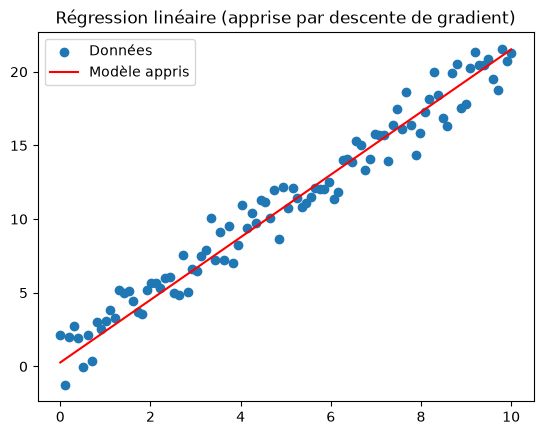

In [ ]:
# Le calcul du gradient est isolé : on pourra fournir une autre fonction
# à l'algorithme d'entraînement sans modifier celui-ci.
def gradient_regression_lineaire(x, y, a, b):
    y_pred = f_predict(x, a, b)
    error = y - y_pred
    grad_a = -2 * np.mean(x * error)
    grad_b = -2 * np.mean(error)
    return grad_a, grad_b


def afficher_ajustement(x, y, a, b, epoch, erreur):
    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, label="Données")
    plt.plot(x, f_predict(x, a, b), color="red", label="Droite estimée")
    plt.title(f"Époque {epoch} — MSE = {erreur:.4f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def descente_gradient(x, y, fonction_gradient, lr=0.01, nb_epochs=200,
                      afficher_tous_les=20, seed=0):
    # Initialisation reproductible des paramètres de la droite.
    generateur = np.random.default_rng(seed)
    a = generateur.standard_normal()
    b = generateur.standard_normal()
    historique = []

    for epoch in range(nb_epochs):
        # La fonction reçue en paramètre décide comment calculer le gradient.
        grad_a, grad_b = fonction_gradient(x, y, a, b)
        a -= lr * grad_a
        b -= lr * grad_b

        y_pred = f_predict(x, a, b)
        erreur = mse(y, y_pred)
        historique.append(erreur)

        if epoch % afficher_tous_les == 0:
            print(f"Époque {epoch:3d} : MSE = {erreur:.4f}")
            afficher_ajustement(x, y, a, b, epoch, erreur)

    return a, b, historique


# Appel de la fonction d'entraînement.
a_estime, b_estime, historique = descente_gradient(
    x, y,
    fonction_gradient=gradient_regression_lineaire,
    lr=0.01,
    nb_epochs=200,
    afficher_tous_les=20,
    seed=0
)

print(f"\nParamètres appris : a = {a_estime:.2f}, b = {b_estime:.2f}")


<div style="background-color:#e8f1fa; border-left:4px solid #3498db; padding:0.5em;"> 
Qu'observez-vous ?
</div>

Réponse : [double-cliquer pour répondre]

> ❓ **Réflexion : quelle est la différence avec la méthode "classique" pour déterminer l’équation d’une droite ?**

En mathématiques, on apprend à déterminer directement les paramètres `a` et `b` de l’équation `y = a·x + b` à partir de deux points.

Ici, ce que nous faisons est un peu différent :  
Nous imitons **un processus d'apprentissage**, comme si l’ordinateur **découvrait peu à peu** les bons paramètres.

👉 On part avec une **estimation approximative**, puis on **observe l’erreur** (l’écart entre ce que le modèle prédit et la réalité),  et on **corrige les paramètres petit à petit** pour réduire cette erreur.

À travers cet exemple, on illustre le **processus itératif d'apprentissage par essai-erreur** des algorithmes d'apprentissage automatique englobés dans le terme d'IA.

> On pourra insister sur **les étapes  de l'apprentissage**  (assez universelles)
> * identifier les paramètres que l'on cherche (ici ``a`` et ``b``)
> * définir une fonction d'erreur (ici ``MSE``)
> * trouver les paramètres qui minimisent l'erreur sur nos données (ici les
    points). C'est un problème d'optimisation (qui sera un peu toujours
    en boîte noire ici)

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<strong>  🧑‍🏫 Pour aller plus loin</strong> <br>
</div>

Serait-il intéressant de leur montrer un cas non-linéaire ?

## Activité 2 - Perceptron (Temps estimé : 20min)

### Mise en pratique

#### Visualisation des données

##### 🔁 Exécutez les cellules suivantes

In [29]:
data = np.load("jeu4.npz")
x = data["X"]
y = data["y"]
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (100, 2)
y shape: (100,)


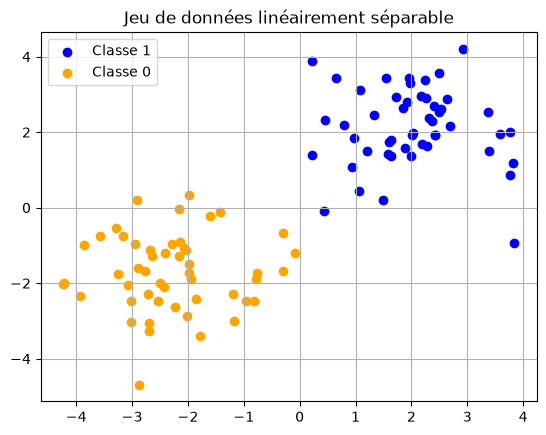

In [30]:
# Affichage du jeu de données
plt.scatter(x[y==1, 0], x[y==1, 1], color='blue', label='Classe 1')
plt.scatter(x[y==0, 0], x[y==0, 1], color='orange', label='Classe 0')
plt.title("Jeu de données linéairement séparable")
plt.legend()
plt.grid(True)
plt.show()


> Comment discuter des coordonnées ? (x,y) ou (x1,x2) ?

> Leur présenter simplement que la frontière qui sépare les deux classes va être estimée à l'aide d'un perceptron.  Cela pourrait aussi être résolu par régression logistique
> 
> Faire le parallèle avec chien et chat
> 
> Comment ça marche ? On prend x à deux caractéristiques, on fait la combinaison linéaire un peu comme on fait en régression x1*w1 + x2*w2 + biais sur cette sortie on applique une fonction à seuil qui permettra de dire si c'est la classe orange ou bleue.
> 
> 👉 Cela correspond à une **composition de fonctions** (vu qu'en terminale).
> 
> Penser à illustre au tableau le neurone de la même manière que : https://user.oc-static.com/upload/2018/12/10/15444553183515_neuroneformel-1.png
> 
> Penser à illustrer la fonction Heaviside

#### Apprentissage

In [ ]:
# Fonction d'activation : seuil 
# La fonction de seuil (step) transforme le score z en une sortie binaire (0 ou 1)
# Si z >= 0 : sortie = 1, sinon sortie = 0
def step(z):
    # np.asarray permet d'utiliser la même fonction avec un nombre ou un tableau.
    return (np.asarray(z) >= 0).astype(int)


def prediction_perceptron(x, poids, biais):
    # Pour chaque point : z = x1*w1 + x2*w2 + biais.
    scores = np.dot(x, poids) + biais
    return step(scores)


def gradient_perceptron(x, y, poids, biais):
    predictions = prediction_perceptron(x, poids, biais)
    erreurs = y - predictions

    # On moyenne les corrections proposées par tous les points.
    # erreurs[:, None] transforme les erreurs en une colonne pour pouvoir
    # multiplier chaque point (x1, x2) par l'erreur correspondante.
    gradient_poids = -np.mean(erreurs[:, None] * x, axis=0)
    gradient_biais = -np.mean(erreurs)
    return gradient_poids, gradient_biais


def afficher_frontiere(x, y, poids, biais, epoch, erreur):
    x_values = np.linspace(x[:, 0].min() - 1, x[:, 0].max() + 1, 100)

    plt.figure(figsize=(6, 4))
    plt.scatter(x[y == 1, 0], x[y == 1, 1], color='blue', label='Classe 1')
    plt.scatter(x[y == 0, 0], x[y == 0, 1], color='orange', label='Classe 0')

    # La frontière correspond aux points pour lesquels
    # poids[0]*x1 + poids[1]*x2 + biais = 0.
    if abs(poids[1]) > 1e-12:
        y_values = -(poids[0] * x_values + biais) / poids[1]
        plt.plot(x_values, y_values, color='green', label='Frontière estimée')

    plt.title(f"Époque {epoch} — proportion d'erreurs = {erreur:.2%}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def entrainer_perceptron(x, y, fonction_gradient, lr=0.1, nb_epochs=100,
                         afficher_tous_les=20, seed=0):
    # On initialise deux poids car chaque point possède deux coordonnées : x1 et x2.
    generateur = np.random.default_rng(seed)
    poids = generateur.standard_normal(2)
    biais = generateur.standard_normal()
    historique = []

    for epoch in range(nb_epochs):
        # Le calcul de la direction de correction est confié à la fonction
        # reçue en paramètre. On pourra donc facilement en tester une autre.
        gradient_poids, gradient_biais = fonction_gradient(
            x, y, poids, biais
        )

        # On avance d'un petit pas dans la direction opposée au gradient.
        poids -= lr * gradient_poids
        biais -= lr * gradient_biais

        predictions = prediction_perceptron(x, poids, biais)
        erreur = mse(y, predictions)
        historique.append(erreur)

        # Toutes les 20 époques, on observe le déplacement de la frontière.
        if epoch % afficher_tous_les == 0:
            print(f"Époque {epoch:3d} : proportion d'erreurs = {erreur:.2%}")
            afficher_frontiere(x, y, poids, biais, epoch, erreur)

    return poids, biais, historique

w, b, historique_perceptron = entrainer_perceptron(
    x, y,
    fonction_gradient=gradient_perceptron,
    lr=0.1,
    nb_epochs=100,
    afficher_tous_les=20,
    seed=0
)

print("Poids appris :", w)
print("Biais appris :", b)
print("Proportion finale d'erreurs :", historique_perceptron[-1])

Poids appris : [1.4685647  1.07389356]
Biais appris : -0.47435685639939607
Erreur : 0.0


#### Analyse du résultat

##### Vérification des prédictions

In [ ]:
print("Prédictions du perceptron :")
for i in range(len(x)): #leur faire coder
    z = np.dot(x[i], w) + b
    print(f"Entrée {x[i]} -> Prédit : {step(z)}")

Prédictions du perceptron :
Entrée [1.8861718  1.58422548] -> Prédit : 1
Entrée [2.63684678 2.87909909] -> Prédit : 1
Entrée [3.38930211 1.50947842] -> Prédit : 1
Entrée [2.24264612 3.38073794] -> Prédit : 1
Entrée [1.49729619 0.19982995] -> Prédit : 1
Entrée [1.9898602  1.35663277] -> Prédit : 1
Entrée [1.96609018 3.30672773] -> Prédit : 1
Entrée [1.92861869 2.79460023] -> Prédit : 1
Entrée [ 3.83947096 -0.92699157] -> Prédit : 1
Entrée [3.36833588 2.5375809 ] -> Prédit : 1
Entrée [3.81043447 1.19625083] -> Prédit : 1
Entrée [3.763008   1.99256811] -> Prédit : 1
Entrée [0.64920777 3.43459601] -> Prédit : 1
Entrée [1.60106714 1.73571552] -> Prédit : 1
Entrée [1.32611139 2.45467975] -> Prédit : 1
Entrée [2.40765527 2.68149685] -> Prédit : 1
Entrée [1.85361799 2.6298556 ] -> Prédit : 1
Entrée [2.68464691 2.17597515] -> Prédit : 1
Entrée [2.18335104 1.68909496] -> Prédit : 1
Entrée [2.02800198 1.9659687 ] -> Prédit : 1
Entrée [1.20353222 1.4927065 ] -> Prédit : 1
Entrée [ 0.43894863 -0.08

##### Visualisation des résultats

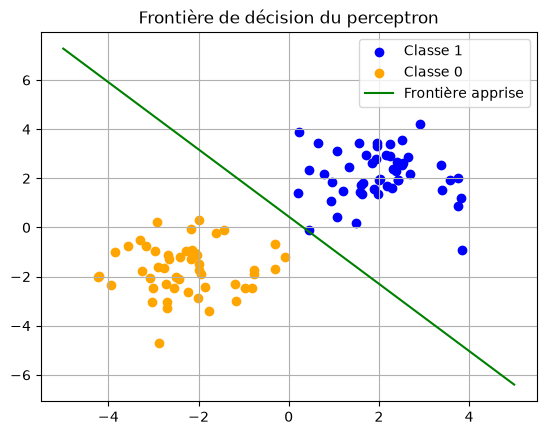

In [ ]:
# Visualisation de la frontière de décision
x_values = np.linspace(-5, 5, 100)
y_values = -(w[0]/w[1]) * x_values - b/w[1]

plt.scatter(x[y==1, 0], x[y==1, 1], color='blue', label='Classe 1')
plt.scatter(x[y==0, 0], x[y==0, 1], color='orange', label='Classe 0')
plt.plot(x_values, y_values, color='green', label='Frontière apprise')
plt.legend()
plt.grid(True)
plt.title("Frontière de décision du perceptron")
plt.show()

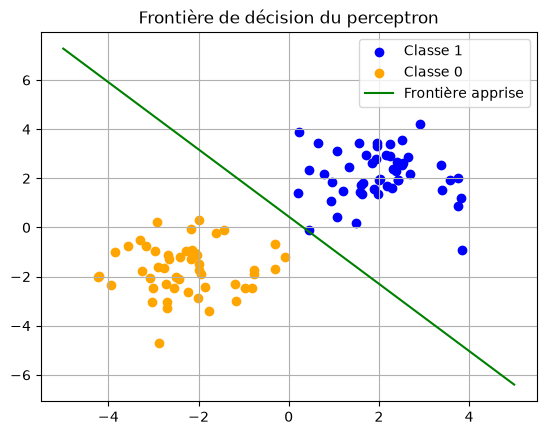

In [ ]:
# Visualisation de la frontière de décision
x_values = np.linspace(-5, 5, 100)
y_values = -(w[0]/w[1]) * x_values - b/w[1]

plt.scatter(x[y==1, 0], x[y==1, 1], color='blue', label='Classe 1')
plt.scatter(x[y==0, 0], x[y==0, 1], color='orange', label='Classe 0')
plt.plot(x_values, y_values, color='green', label='Frontière apprise')
plt.legend()
plt.grid(True)
plt.title("Frontière de décision du perceptron")
plt.show()

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<strong>  🧑‍🏫 Pour aller plus loin: cas fonction non-linéaire </strong> <br>
</div>

Dans l'exemple précédent, les données sont dites **linéairement séparables** : une droite suffit pour séparer les deux classes.
Un perceptron simple ne peut apprendre qu'une frontière de décision droite.

> ❓ Connaissent-t-ils des fonctions non-linéaires ?

Nous allons maintenant construire des données séparées par une **parabole** d'équation $x_2 = x_1^2 - 2$. Cette frontière est non linéaire : aucune droite ne pourra parfaitement séparer les deux couleurs.

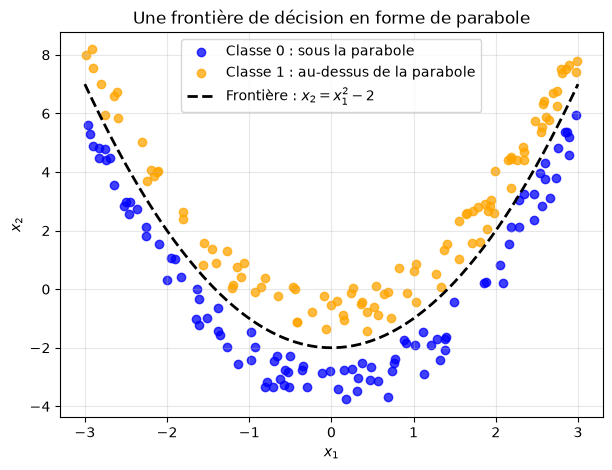

In [3]:
# Le générateur permet de retrouver exactement les mêmes points
# chaque fois que la cellule est exécutée.
generateur = np.random.default_rng(0)
nombre_points = 200

# Première coordonnée de chaque point, choisie entre -3 et 3.
x1 = generateur.uniform(-3, 3, nombre_points)

# On choisit au hasard la classe 0 ou la classe 1.
y_parabole = generateur.integers(0, 2, nombre_points)

# La frontière que l'on veut faire apparaître est la parabole x2 = x1² - 2.
frontiere = x1**2 - 2

# Les points de classe 1 sont placés au-dessus de la parabole ;
# ceux de classe 0 sont placés en dessous. Un léger bruit rend
# le jeu de données moins artificiel.
distance = generateur.uniform(0.4, 2.0, nombre_points)
bruit = generateur.normal(0, 0.15, nombre_points)
x2 = frontiere + np.where(y_parabole == 1, distance, -distance) + bruit

# Chaque ligne contient maintenant les deux coordonnées (x1, x2) d'un point.
X_parabole = np.column_stack((x1, x2))

# Affichage des deux classes.
plt.figure(figsize=(7, 5))
plt.scatter(X_parabole[y_parabole == 0, 0], X_parabole[y_parabole == 0, 1],
            color='blue', alpha=0.75, label='Classe 0 : sous la parabole')
plt.scatter(X_parabole[y_parabole == 1, 0], X_parabole[y_parabole == 1, 1],
            color='orange', alpha=0.75, label='Classe 1 : au-dessus de la parabole')

# On trace la véritable frontière pour aider à la reconnaître.
x_frontiere = np.linspace(-3, 3, 200)
plt.plot(x_frontiere, x_frontiere**2 - 2, 'k--', linewidth=2,
         label=r'Frontière : $x_2 = x_1^2 - 2$')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title("Une frontière de décision en forme de parabole")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("classification_nonlinear.png")
plt.show()
plt.close()

## Activité 3 - Perceptron multi-couches (temps estimé 30min)

On va maintenant travailler sur un autre type de modèle = réseau de neurones (ce qui se cache derrière ChatGPT) <br>
Neurone = fonction mathématique (on pourra écrire $y = f(x)$) <br>
L'entrée x de ce modèle ça va être une image <br>
La sortie y ça va être le chiffre qui est dessiné sur l'image. On passe à un problème à 10 classes.

#### Proposition déroulement

Donner quelques explications sur le réseau de neurones (ne pas mentionner la normalisation)

sortie = autant de « neurones » que de chiffres manuscrits (une proba par chiffre)

On prend le chiffre avec la plus grande probabilité

On visualise cela sous forme de tableau (peut-être éviter argmax)

Ils peuvent passer plus de temps sur le dessin de chiffres

Leur faire un premier modèle avec le 1

Les laisser réfléchir avec un autre chiffre et corriger

#### Chargement de bibliothèques Python supplémentaires

In [36]:
import warnings
warnings.simplefilter("ignore")

# keras est une bibliothèque qui permet de construire facilement des intelligences artificielles
# On l’utilisera plus tard pour entraîner une IA à reconnaître des chiffres
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

ModuleNotFoundError: No module named 'tensorflow'

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<b> Commentaire :</b> ne pas faire attention aux messages d'erreur ici
</div>


On va maintenant travailler sur les images numériques.

#### 🖼️ Qu’est-ce qu’une image numérique ?

> Une image est formée de milliers de petits points appelés pixels. On s'intéresse ici aux images en noir et blanc.
> 
> Chaque pixel contient une valeur entre 0 et 1 :
> - 0 = noir
> - 1 = blanc
> - une valeur entre les deux = une nuance de gris

Une image en niveaux de gris peut donc être représentée par une matrice de nombres (tableau de tableau), où chaque case correspond à un pixel.

Par exemple, une image en 28x28 pixels (comme dans MNIST) est un tableau avec 28 lignes et 28 colonnes.

<div style="background-color:#fff9db; border-left:4px solid #f1c40f; padding:0.8em; font-size: 0.95em;">
<b> Commentaire :</b> pour insister sur la grande dimension, préciser qu'une image dans la vraie vie : c'est 1200x1800 pour 4 flottants par pixels, soit autour de 8,6 millions de variables.
</div>


##### 🔁 Exécutez la cellule suivante

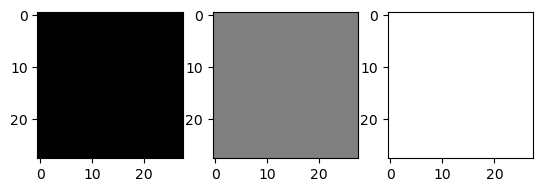

In [23]:
plt.figure()
plt.subplot(1, 3, 1)
img_black = np.full((28, 28), 0.0)
plt.imshow(img_black, cmap='gray', vmin=0.0, vmax=1.0)
plt.subplot(1, 3, 2)
img_gray = np.full((28,28), 0.5)
plt.imshow(img_gray, cmap='gray', vmin=0.0, vmax=1.0)
plt.subplot(1, 3, 3)
img_white = np.full((28,28), 1.0)
plt.imshow(img_white, cmap='gray', vmin=0.0, vmax=1.0)
plt.show()

#### ✏️ Q1) Sur la base d'une image toute noire, essayez de faire apparaître le chiffre "1"

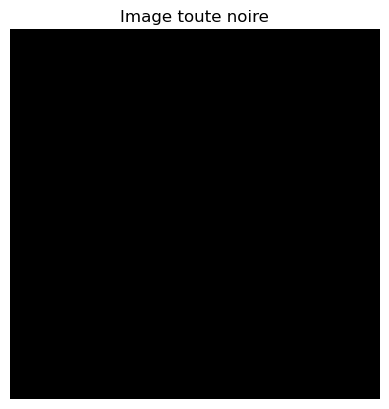

In [8]:
# Créer une image 28x28 noire (valeurs 0)
img = np.zeros((28, 28))

# Affichage
plt.imshow(img, cmap='gray')
plt.title("Image toute noire")
plt.axis('off')
plt.show()

Observez le contenu de la matrice

In [35]:
img

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

<div style="background-color:#f9f9f9; border-left:4px solid #0074D9; padding:0.5em; font-style: italic;">
Correction
</div>

Voici une image toute noire avec le premier pixel en blanc (valeur 255) :

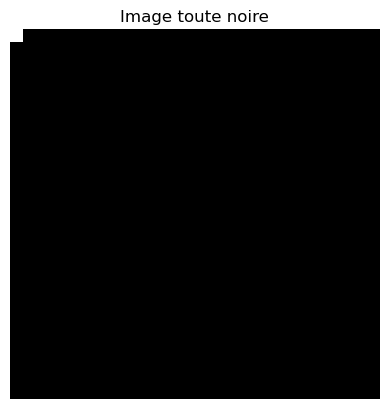

In [5]:
# Créer une image 28x28 noire (valeurs 0)
img = np.zeros((28, 28))

# Modification de la couleur du premier pixel en blanc (valeur 255)
img[0,0]=1.0

# Affichage
plt.imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
plt.title("Image toute noire")
plt.axis('off')
plt.show()

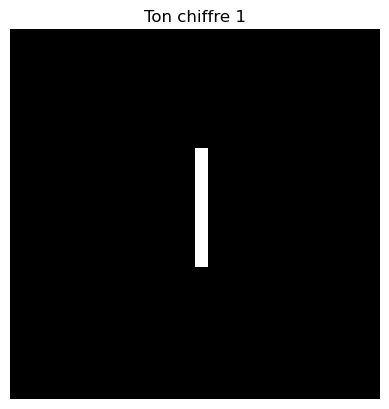

In [6]:
# Étape 1 : Créer une image noire (tout à 0)
img = np.zeros((28, 28))

# Étape 2 : Dessiner un "1" vertical
for i in range(9, 18):     # ligne de 5 à 22
    img[i, 14] = 1.0        # colonne centrale allumée

# Étape 3 : Afficher l’image
plt.imshow(img, cmap='gray',vmin=0,vmax=1)
plt.title("Ton chiffre 1")
plt.axis('off')
plt.show()

### ✏️ Q2) Application du réseau de neurones

Un **réseau de neurones simple** (à une couche cachée) vous est fourni.
Essayez de **le tester** sur différents chiffres entre **1 et 9** que vous dessinerez vous-mêmes.

💡 Vous pouvez aussi tenter de **tromper le modèle** en dessinant des chiffres avec une **forme ambiguë** !

🎨 **Amusez-vous et observez les prédictions !**

In [ ]:
#Chargement des données MNIST 

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(images, classes), _ = mnist.load_data()  #chargement des données
n = images.shape[0] #taille de l'échantillon de données
images = images.reshape(n, 28*28) / 255.0 #normalisation
classes = to_categorical(classes) # associer un chiffre à chaque classe

model_mnist = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
]) #illustrer le modèle au tableau
# étape 1 : vectorisation (entrée d'un MLP - pas toujours nécessaire en fonction du type de NN)
# étape 2 : "projection" dans un espace de plus petite dimension (comment expliquer ça ?) // R^2 / R^3
# insister un neurone = une fonction (ici non-linéaire pont avec les cercles précédemment illustrées
# étape 3 : calcul sortie => un neurone / classe. Chaque neurone i calcule la probabilité d'appartenance au numéro i via la fonction softmax. 
# (supposition : on appartient à une seule classe //proba somme des probas = 1.)
# on parle ici de multi-perceptron à 1 couche cachée. Chatgpt par exemple est construit avec xx couches / param
model_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) 
# optimizer = méthode de descente de gradient / "loss" = erreur (comme erreur absolu
model_mnist.fit(images, classes, epochs=3, batch_size=128)
model_mnist.evaluate(images, classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


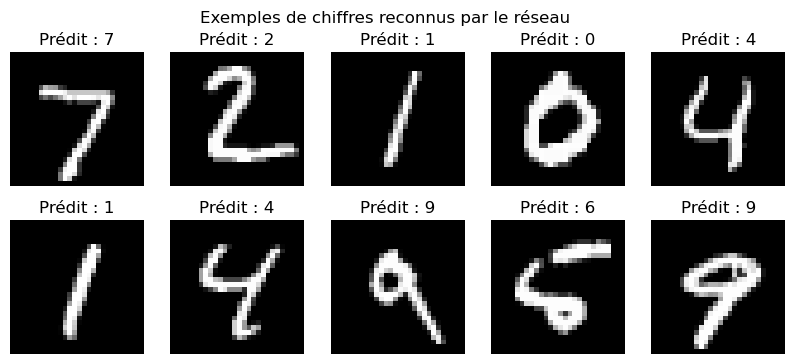

In [33]:
#Visualiser quelques images avec leurs prédictions
plt.figure(figsize=(10,4))
for i in range(10):
    img = x_test[i].reshape(28,28)
    prediction = model_mnist.predict(x_test[i].reshape(1, 28*28))
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray',vmin=0,vmax=1)
    plt.title(f"Prédit : {np.argmax(prediction)}") # on prend la classe de plus grande probabilité
    plt.axis('off')
plt.suptitle("Exemples de chiffres reconnus par le réseau")
plt.show()

In [ ]:
# C'est à vous
# Vous reprendrez les fonctions précédentes

> A) Il crée une image
> 
> B) Donner le code qu'ils auront besoin pour prédire

<div style="background-color:#f9f9f9; border-left:4px solid #0074D9; padding:0.5em; font-style: italic;">
Correction
</div>

In [36]:
np.argmax(model_mnist.predict(img.reshape(1, 28*28)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


9

Mon réseau reconnaît un 9 à la place du 1.

## Conclusion (5'-10')

1. Conclure avec nos travaux en recherche
2. Demander si ça leur a plu ? S’il souhaite récupérer le notebook ?